# Basis Expansion and Regularization
Humans still have to do work too.

## Section 1 : Polynomial Curve Fitting (20 min)
In this section you will implement a polynomial curve fitting algorithm using gradient descent and explore the bias-variance tradeoff.

1. First, let's get some data. Create a function to sample n points from the following distribution:
$$\begin{align*}
X \sim U[0,5] \quad E = N(0, 4) \\
Y = 3x^2 + 2x -3 + E
\end{align*}$$

In [68]:
import numpy as np
import random
import matplotlib.pyplot as plt


def sample_polynomial(n):
    X = np.random.uniform(0, 5, n)
    E = np.random.normal(0, 2, n)
    Y = 3*X**2 + 2*X - 3 + E
    return X, Y

In [69]:
def plot_points(points):
    fig, ax = plt.subplots()
    x, y = sample_polynomial(points)
    ax.scatter(x, y)
    ax.plot(3*x**2 + 2*x -3)
    '''
    plot the points as well as the polynomial itself
    points should be stars and the polynomial should be dashed with alpha=0.4
    '''
    plt.show()
    return

2. Now, let's define our model. Consider our model to be, for some integer n:
$$\begin{align*}
\hat{y} = w_nx^n + w_{n-1}x^{n-1} + ... w_1x + w_0
\end{align*}$$

 Write a fuction that will take an input, n, and initialize an approporiate model.

In [70]:
def init_poly_model(n):
    w = np.ones(n)
    x = np.ones((n, n))
    y_hat = 0
    for i in range(n):
      y_hat += w[i]*x**i
    '''
    This should produce a model (as weights stored in a numpy array)
    with the above definition.

    All weights should be initilized to one
    '''
    return w

In [91]:
def plot_points_and_models(train_datax, train_datay, test_datax, test_datay, models):
    fig, ax = plt.subplots()
    ax.scatter(train_datax, train_datay, color='blue')
    ax.scatter(test_datax, test_datay, color = 'red')
    x = np.linspace(0, 5, 100)
    y_true = 3 * x**2 + 2 * x - 3
    ax.plot(x, y_true, alpha=0.5)
    for i, j in models:
      mf = np.poly1d(i)
      ax.plot(x, mf(x), label=j)
    '''
    Modify your above code to add the ability to plot models alongside
    the data (now training and testing data) and the true polynomial.

    Train data should be blue and test data should be red.

    The models are given as a list of tuples with:
    [0] : numpy array (an n degree model is an n long np array)
    [1] : string to label the model in the plot
    '''
    plt.show()
    pass

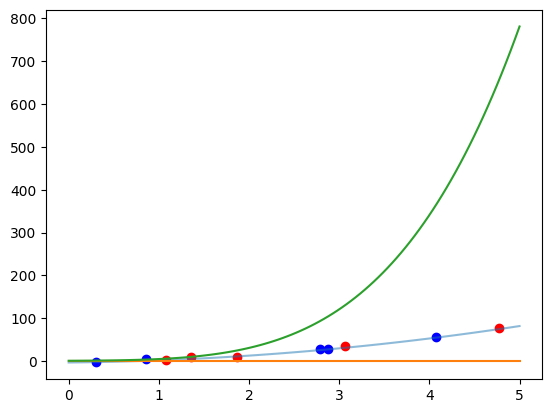

In [108]:
# Test of your code so far

zero_deg = init_poly_model(0)
two_deg = init_poly_model(2)
five_deg = init_poly_model(5)

train_pointsx, train_pointsy = sample_polynomial(5)
test_pointsx, test_pointsy = sample_polynomial(5)
plot_points_and_models(train_pointsx, train_pointsy, test_pointsx, test_pointsy, [(zero_deg, "constant model untrained"), (five_deg, "5 degree model untrained")])

3. Now we train. Implement gradient descent on your polynomial, you may choose the values of your hyperparameters however you like.

In [ ]:
def init_x(model, n):
    return np.vander(model, n, increasing = True)
def lse(x, y, model):
    predictions = np.polyval(model, x)
    err = predictions - y
    loss = np.mean(err**2)
    return loss, err

def gradient_descent(iterations, learning_rate, model, train_datax, train_datay, test_datax, test_datay):
    train_losses = []
    test_losses = []
    for i in range(iterations):
      x = init_x(model, 2)
      trloss, trerr = lse(train_datax, train_datay, x)
      teloss, teerr = lse(test_datax, test_datay, x)





    '''
    Implement gradient descent using LSE as loss on your polynomial model
    in each iteration of training you should record both the train loss and test loss
    All should be returned as numpy arrays.

    You may create helper functions for this implementation, such as one to calculate the gradient.
    '''

    return final_model, train_losses, test_losses

In [ ]:
# Testing -- you may need to tune learning rate

trained_two_degree = gradient_descent(10, 0.0001, two_deg, train_pointsx, train_pointsy, test_pointsx, test_pointsy)
trained_five_degree = gradient_descent(10, 0.0001, five_deg, train_pointsx, train_pointsy, test_pointsx, test_pointsy)

plot_points_and_models(train_points, test_points, [(trained_two_degree, "Two degree model trained"), (trained_five_degree, "five degree model trained")])

'''
TODO plot the learning curves (train and test) as well
'''

## Section 2 : Smarter Polynomial Curve Fitting (20 min)

1. First we will define a polynomial basis expansion. That is, given some degree d we will create a new input dataset, $\phi(x)$, like so:
$$
\begin{align*}
\phi(x) = [x^d, x^{d-1}, ..., x^{1}, 1]
\end{align*}

In [ ]:
def poly_basis(train_data, d):
    '''
    Returns a numpy array which is a basis expansion of each element of x, this should be an n x (d+1) matrix output.
    Note that x^0 = 1 is included in the basis which allows us to remove bias from a linear layer.

    Reminder train_data[:][0] = x, train_data[:][1] = y
    '''
    return

2. Now we fit it. Recall the optimnal linear fit, $w^*$, given LSE from the previous test:
$$\begin{align*}
w^* = (X^TX)^{-1} \cdot (X^Ty)
\end{align*}$$

In [ ]:
def poly_fit(train_data, test_data, degree):
    '''
    Create a d-degree fit for data input x and output y.
    You must use basis expansion and then use the closed-form linear fit above to achieve this

    Your solution (W*) should be returned as an d+1 long np array.

    You should also return both the training loss and testing loss -- since there are no iterations these will just be scalars
    '''

    return opt_w, train_loss, test_loss

3. Plot your new polynomial fits and answer the following about them

In [ ]:
# Testing

two_deg  = poly_fit(train_points, test_points, 2) # two_deg is a tuple of the returns of poly_fit
five_deg = poly_fit(train_points, test_points, 5) # Same with five_deg

print("Losses of two deg:")
print("Train:", two_deg[1], "      |     Test:", two_deg[2])
print("--------------------------------------------------------")
print("Losses of five deg:")
print("Train:", five_deg[1], "      |     Test:", five_deg[2])

plot_points_and_models(train_points, test_points, [two_deg[0], five_deg[0]])


a. What is the expected optimal training loss (LSE in this case) of an d-degree polynomial trained on n data points with d >= n? Why do we not expect the same for the testing loss?

b. This gap between train and test loss signifies *Overfitting*, suggest two possible approaches to creating a fit to polynomial data that is not overfit, explain why each would reduce overfitting.

## Section 3 : Regularization and Hyperparameter Tuning (20 min)
For this section recall the following loss function and optimal weights:

$$\begin{align*}
 \hat{y} &= X \cdot W\\ \\
 Loss &= \frac{1}{2}(||\hat{y} - y||_2^2 + \lambda ||W||_2^2) \\ \\
 W^* &= (X^TX+\lambda I)^{-1}X^Ty
\end{align*}$$

This Loss function is *regularized* Least Squared Error (LSE). The additional term $\lambda ||W||_2^2$ quantifies the magnitude of W. That is, this loss function is larger for models with high magnitude weights, and as such the optimal solutions produced by this will be lower magnitude in general. The $\lambda$ term is a hyperparameter which can be chosen to tune how much this loss function "cares about" the magnitude of the weights.

1. Write a function to create an optimal d-degree polynomial for given data and regularization factor (lambda)

In [ ]:
def regularized_poly_fit(train_data, test_data, degree, lam):
    '''
    modify your poly fit model to add regularization
    '''
    return opt_w, train_loss, test_loss

2. To determine a good setting to our hyperparameters we'll do a grid search over possible choices of degree and lambda and plot the results.

In [ ]:
def grid_search(lambdas=[0, 0.25, 0.5, 0.75, 1], degrees=[1,2,3,4,5,6,7]):
    '''
    Train a model with each combination of the values in the lambdas and degrees lists

    This should return 2 2d np arrays, 1 with training losses, the other with test losses.
    '''

    return train_losses, test_losses


In [ ]:
# plot these matrices as seaborn heatmaps

import seaborn as sn

train_losses, test_losses = grid_search()

3. Using this result and any other method of your choosing produce a single best model, we will then test this on newly sampled data to see how well it generalizes.

In [ ]:
# Use this block to produce your best_model however you'd like

In [ ]:
# Testing your best_model

new_test_points = sample_polynomial(100)
loss = 0 # calculate the LSE of your best_model on these new points

print(loss)